# Machine Learning Model for Medicaid Expansion Impact: results

**In short:** this notebook shows how much Medicaid expansion itself reduced the share of low-income adults without
health insurance, whether that result holds up, and what a machine learning model predicts for the 10 states that
have not expanded. Data: Census estimates for 3,035 US counties, 2008-2023, prepared in PostgreSQL by the companion
analytics project.

1. **Dataset**: the county panel exported by `01_build_dataset.py`.
2. **Effect of expansion**: staggered difference-in-differences (`02_causal_effects.py`).
3. **Machine learning**: causal forest, validation on held-out states, predictions (`03_train_causal_forest.py`).

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
pd.set_option("display.float_format", "{:,.2f}".format)
panel = pd.read_csv(ROOT / "Data" / "county_panel.csv.gz", dtype={"county_fips": str})
cr = json.loads((ROOT / "models" / "causal_results.json").read_text())
mr = json.loads((ROOT / "models" / "ml_results.json").read_text())
print(f"{len(panel):,} county-years, {panel.county_fips.nunique():,} counties, {panel.state_abbrev.nunique()} states, "
      f"{panel.year.min()}-{panel.year.max()}")
panel.groupby("analysis_group").county_fips.nunique().rename("counties").to_frame()

48,560 county-years, 3,035 counties, 45 states, 2008-2023


,counties
analysis_group,
Expanded 2014,1078
Expanded 2015-2017,314
Expanded 2019-2022,507
Not expanded by 2023,1136


## 1. How much did expansion itself change the uninsured rate?

Each expansion county's change is compared with the change in similar counties in states that did not expand over
the same years (Callaway & Sant'Anna 2021), adjusted for 2013 county traits, weighted by population, with 95%
intervals from 499 bootstrap resamples of states.

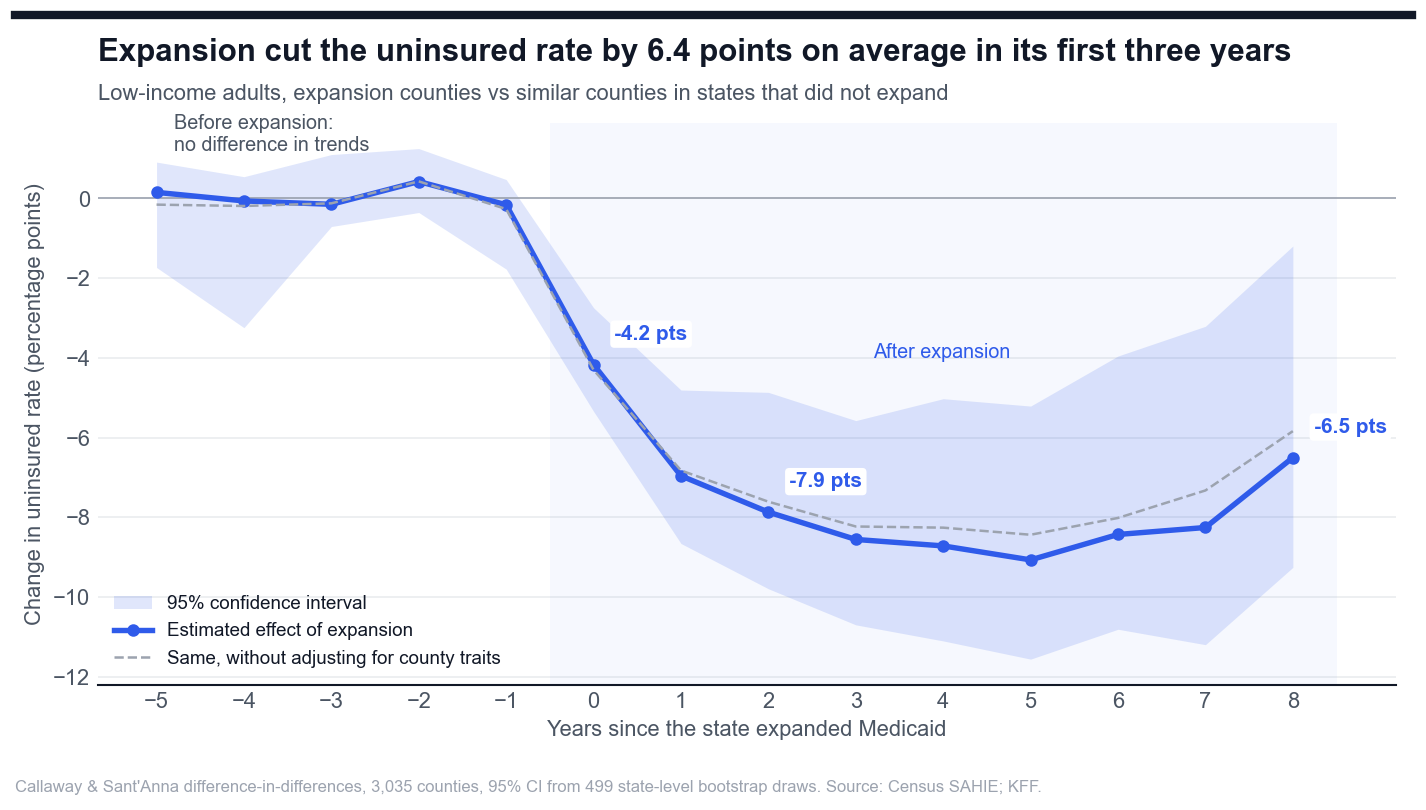

,estimate (pts),95% CI
"Main: covariate-adjusted, years 0-2",-6.41,-7.8 to -4.2
"Unadjusted, years 0-2",-6.33,-8.0 to -4.6
Adults 138-400% FPL (not made eligible),-2.76,-3.9 to -1.4
Placebo: fake 2011 expansion,0.04,-0.8 to 1.4
"Adjusted, all post years",-7.40,
Two-way fixed effects (traditional),-7.08,


In [2]:
display(Image(ROOT / "Image" / "01_event_study.png"))
pd.DataFrame({
    "estimate (pts)": [cr["adjusted"]["att_years_0_2"], cr["unadjusted"]["att_years_0_2"], cr["placebo_138_400"]["att_years_0_2"],
                       cr["placebo_fake_2011"]["att"], cr["adjusted"]["att_all_post_years"], cr["twfe"]],
    "95% CI": [f"{a:.1f} to {b:.1f}" for a, b in [cr["adjusted"]["ci"], cr["unadjusted"]["ci"], cr["placebo_138_400"]["ci"],
                                                  cr["placebo_fake_2011"]["ci"]]] + ["", ""],
}, index=["Main: covariate-adjusted, years 0-2", "Unadjusted, years 0-2", "Adults 138-400% FPL (not made eligible)",
          "Placebo: fake 2011 expansion", "Adjusted, all post years", "Two-way fixed effects (traditional)"])

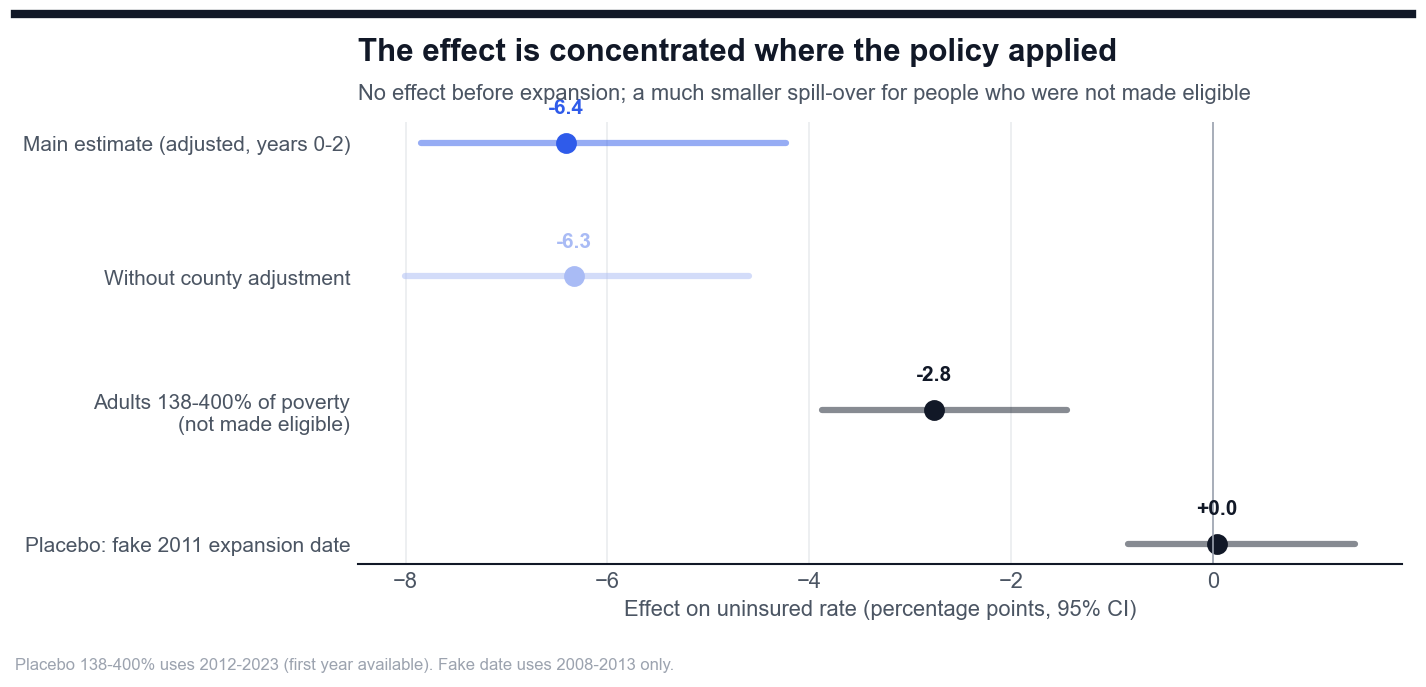

Low-income adults insured in 2023 because of expansion (33 expansion states studied): 968,009 (95% CI 236,664 to 1,286,218)


,expansion_year,att_year_2,counties
0,2014,-8.28,1078
1,2015,-6.41,169
2,2016,-8.97,81
3,2017,-8.32,64
4,2019,-7.39,149
5,2020,-3.22,73
6,2021,-1.90,93


In [3]:
display(Image(ROOT / "Image" / "02_robustness_checks.png"))
print(f"Low-income adults insured in 2023 because of expansion (33 expansion states studied): "
      f"{cr['people_covered_2023']['estimate']:,.0f} (95% CI {cr['people_covered_2023']['ci'][0]:,.0f} to {cr['people_covered_2023']['ci'][1]:,.0f})")
pd.read_csv(ROOT / "Data" / "results" / "causal_by_cohort.csv")

## 2. Machine learning: which counties gain the most?

A causal forest (EconML `CausalForestDML`) estimates a separate effect for every county from its pre-expansion traits.
It must agree with the difference-in-differences estimate on average, and on states held out of training, the counties
it predicts will gain more must really have gained more.

Causal forest average effect: -6.46 pts (difference-in-differences: -6.41 pts)


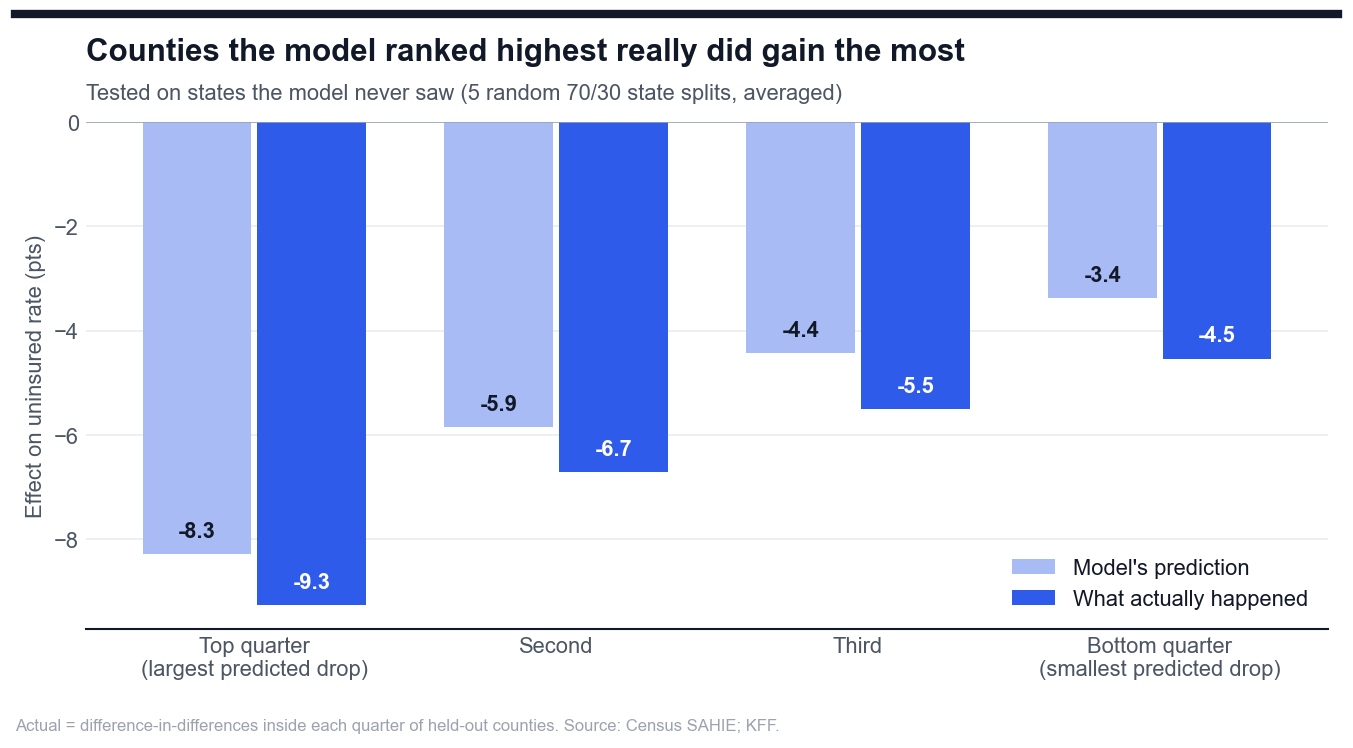

,split,gap_top_vs_bottom_predicted,gap_top_vs_bottom_actual
0,0,-6.71,-3.59
1,1,-5.40,-9.04
2,2,-4.88,0.96
3,3,-2.39,-5.19
4,4,-4.05,-6.82


In [4]:
print(f"Causal forest average effect: {mr['forest_ate_expansion_counties']:.2f} pts "
      f"(difference-in-differences: {mr['did_estimate_years_0_2']:.2f} pts)")
display(Image(ROOT / "Image" / "03_model_validation.png"))
pd.DataFrame(mr["validation_splits"])[["split", "gap_top_vs_bottom_predicted", "gap_top_vs_bottom_actual"]]

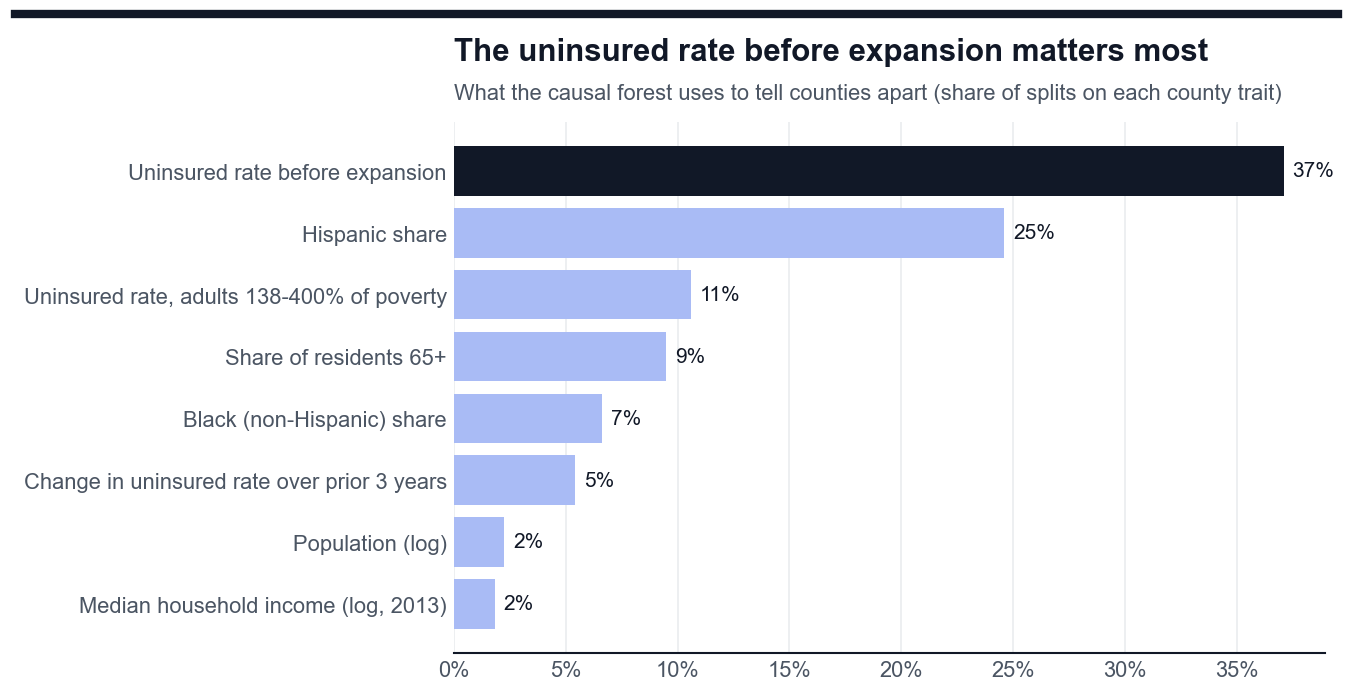

,Metro,Remote rural,"Rural, near a metro",Lowest poverty,Low-mid,Mid-high,Highest poverty,Lowest,Highest
rurality,-6.38,-7.33,-6.61,NaN,NaN,NaN,NaN,NaN,NaN
poverty_band,NaN,NaN,NaN,-5.46,-5.58,-6.94,-7.05,NaN,NaN
base_band,NaN,NaN,NaN,NaN,-5.06,-6.07,NaN,-4.02,-8.20


In [5]:
display(Image(ROOT / "Image" / "04_effect_drivers.png"))
pd.DataFrame(mr["effect_by"]).T

## 3. What if the 10 remaining states expanded?

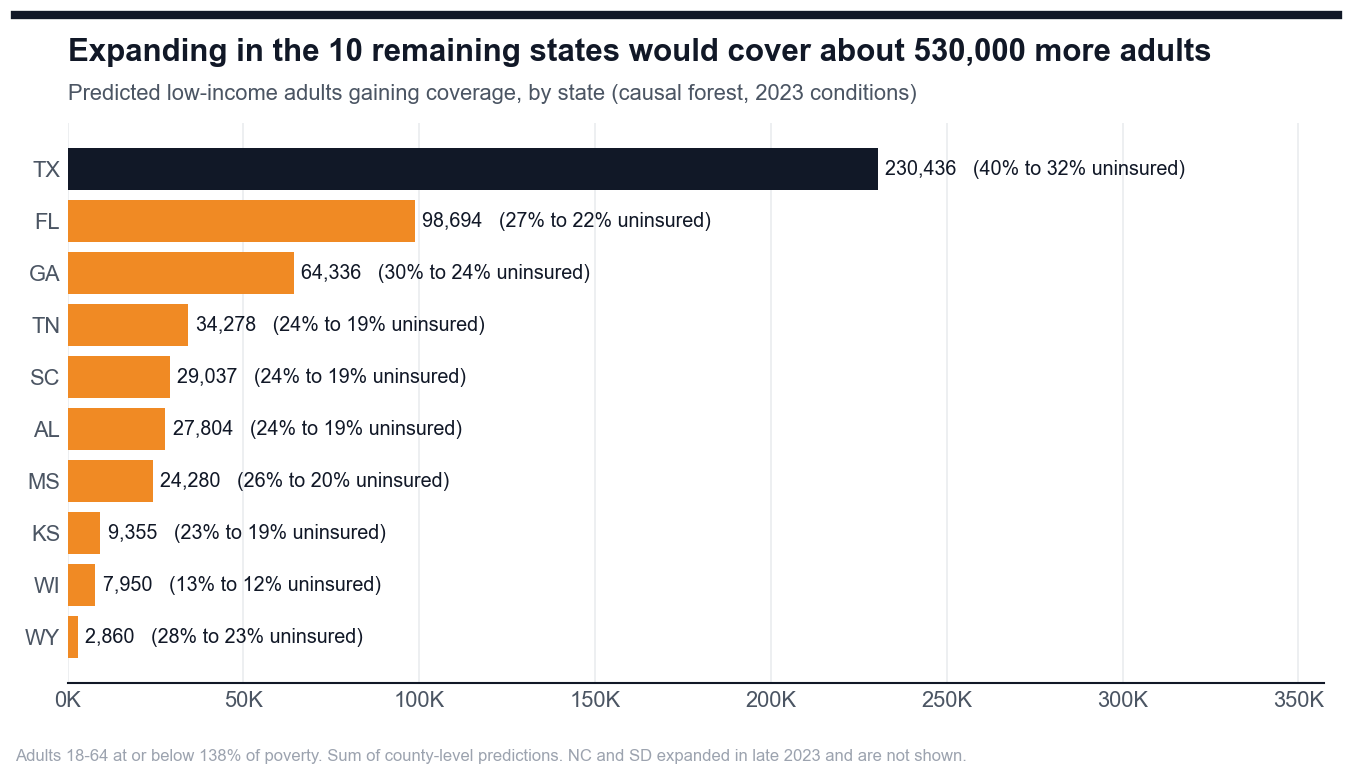

,county_name,state,rurality,base_rate,predicted_effect_pts,effect_lo,effect_hi,adults_gaining_coverage
0,Harris County,TX,Metro,45.70,-6.98,-10.30,-3.65,"40,248.50"
1,Dallas County,TX,Metro,45.10,-6.96,-9.98,-3.95,"19,709.71"
2,Bexar County,TX,Metro,35.30,-7.46,-10.12,-4.81,"18,153.82"
3,Miami-Dade County,FL,Metro,27.70,-5.50,-8.83,-2.17,"16,165.63"
4,Hidalgo County,TX,Metro,47.30,-9.32,-12.36,-6.28,"14,723.37"
5,Tarrant County,TX,Metro,39.90,-6.22,-7.68,-4.77,"12,324.60"
6,El Paso County,TX,Metro,44.30,-9.81,-12.06,-7.57,"11,998.91"
7,Cameron County,TX,Metro,44.70,-11.39,-13.38,-9.40,"8,062.09"
8,Broward County,FL,Metro,27.90,-3.96,-4.99,-2.94,"6,989.71"
9,Travis County,TX,Metro,30.60,-5.55,-6.70,-4.40,"6,662.66"


In [6]:
display(Image(ROOT / "Image" / "05_nonexpansion_predictions.png"))
top = pd.read_csv(ROOT / "Data" / "results" / "ml_nonexpansion_county_predictions.csv")
top = top[~top.state.isin(["NC", "SD"])]
top.head(15)[["county_name", "state", "rurality", "base_rate", "predicted_effect_pts", "effect_lo", "effect_hi", "adults_gaining_coverage"]]

## Limitations

* SAHIE figures are model-based estimates with margins of error; every model weights counties by population.
* States chose whether to expand; the design removes fixed differences and shared yearly changes, and pre-trends
  match, but a state-specific shock at the same time as expansion would bias the estimate.
* Predictions assume expansion would work as it did in similar counties, under 2023 conditions; they estimate the
  drop in the uninsured rate, not Medicaid enrollment.